# Supervised Learning

This notebook uses simple supervised learning to classify images into classes, with augmentation (random rotation and flips)

In [1]:

cd ..

/home/lowen/Documents/github/galaxy_class


In [2]:
# install requirements

# if connected to colab


if 'google.colab' in str(get_ipython()):
  print('running on colab')
  %pip install git+https://github.com/henrysky/astroNN.git
else:
  %pip install --upgrade pip
  %pip install -r user-requirements.txt

Note: you may need to restart the kernel to use updated packages.
Ignoring tensorflow: markers 'sys_platform != "linux"' don't match your environment
Note: you may need to restart the kernel to use updated packages.


In [3]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import h5py
import numpy as np
from tensorflow.keras import utils
import os

filepath = 'src/Galaxy10.h5'

if not os.path.exists(filepath):
    print(f"file {filepath} not found")
    print("fetching from http://astro.utoronto.ca/~bovy/Galaxy10/Galaxy10.h5...")
    os.makedirs('src', exist_ok=True)
    !wget -P src http://astro.utoronto.ca/~bovy/Galaxy10/Galaxy10.h5

with h5py.File(filepath, 'r') as F:
    images = np.array(F['images'])
    labels = np.array(F['ans'])

# To convert the labels to categorical 10 classes
labels = utils.to_categorical(labels, 10)

# To convert to desirable type
labels = labels.astype(np.float32)
images = images.astype(np.float32)

2026-08-01 21:56:06.668367: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-01 21:56:06.668401: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-01 21:56:06.669540: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-01 21:56:06.675848: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-01 21:56:07.459093: W tensorflow/compiler/tf2

In [4]:
images.shape

(21785, 69, 69, 3)

In [5]:
# divide images and labels into training and test sets

X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.1, random_state=42)

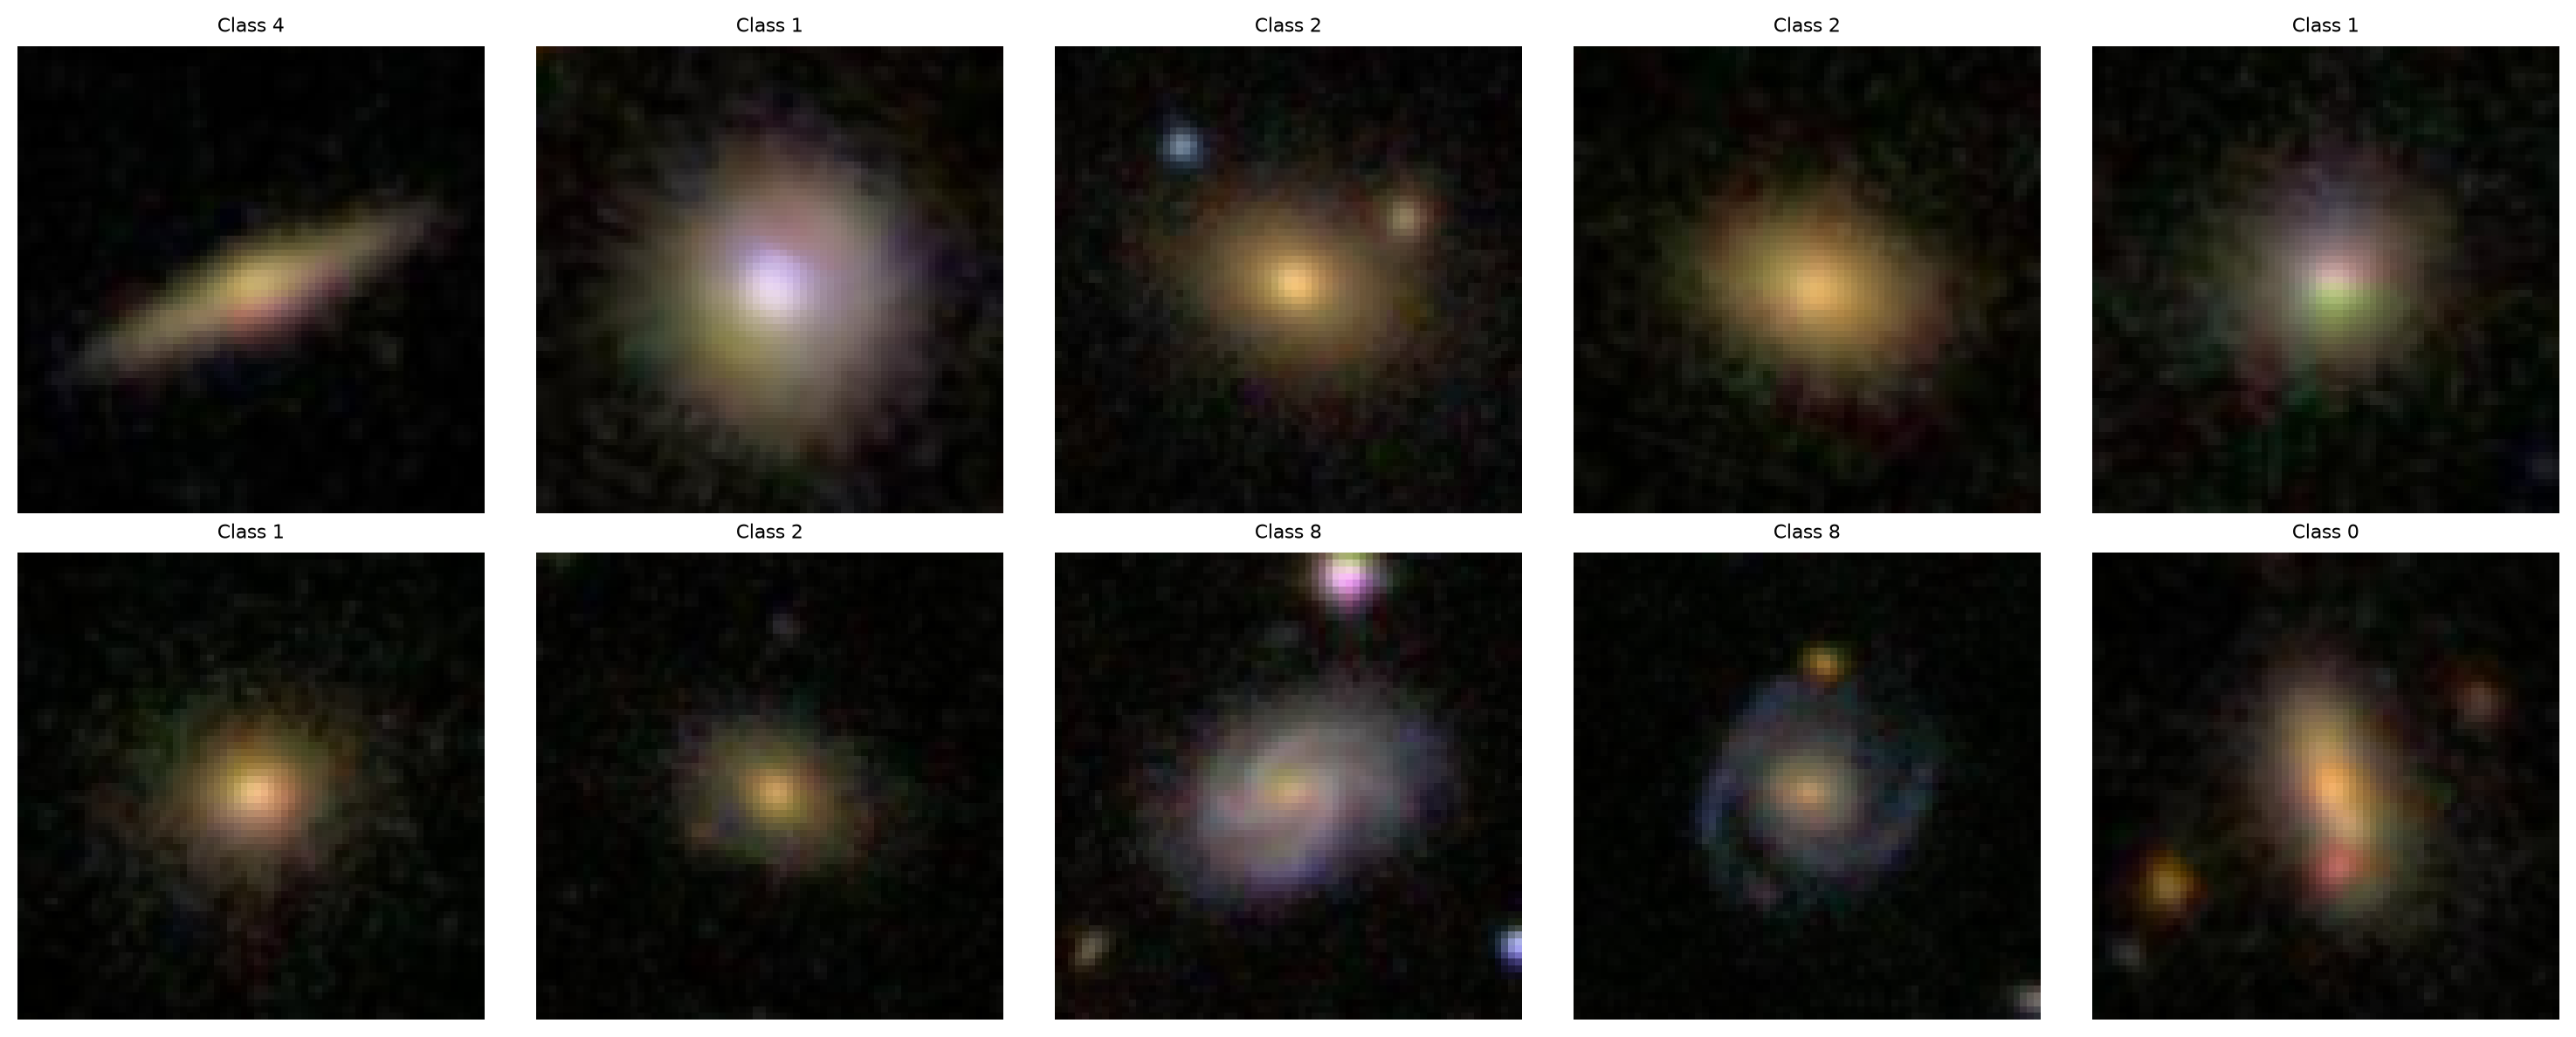

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

idx = np.random.randint(0, y_train.shape[0], size=10)

for ax, i in zip(axes.flat, idx):
    ax.imshow(X_train[i].astype(np.uint8))
    ax.set_title(f"Class {np.argmax(y_train[i])}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
# plt.savefig("plots/original.png")
plt.show()

In [7]:
# def center_crop(img, crop_size):
#     h, w = img.shape[:2]
#     start_h = (h - crop_size) // 2
#     start_w = (w - crop_size) // 2
#     return img[start_h:start_h + crop_size, start_w:start_w + crop_size]

# crop_size = 128
# X_train_cropped = np.array([center_crop(img, crop_size) for img in X_train])
# X_test_cropped = np.array([center_crop(img, crop_size) for img in X_test])

# print(X_train_cropped.shape)

In [8]:
from PIL import Image
import numpy as np

X_train_gray = np.array([
    np.array(Image.fromarray(img.astype(np.uint8)).convert('L'))
    for img in X_train
])

X_test_gray = np.array([
    np.array(Image.fromarray(img.astype(np.uint8)).convert('L'))
    for img in X_test
])

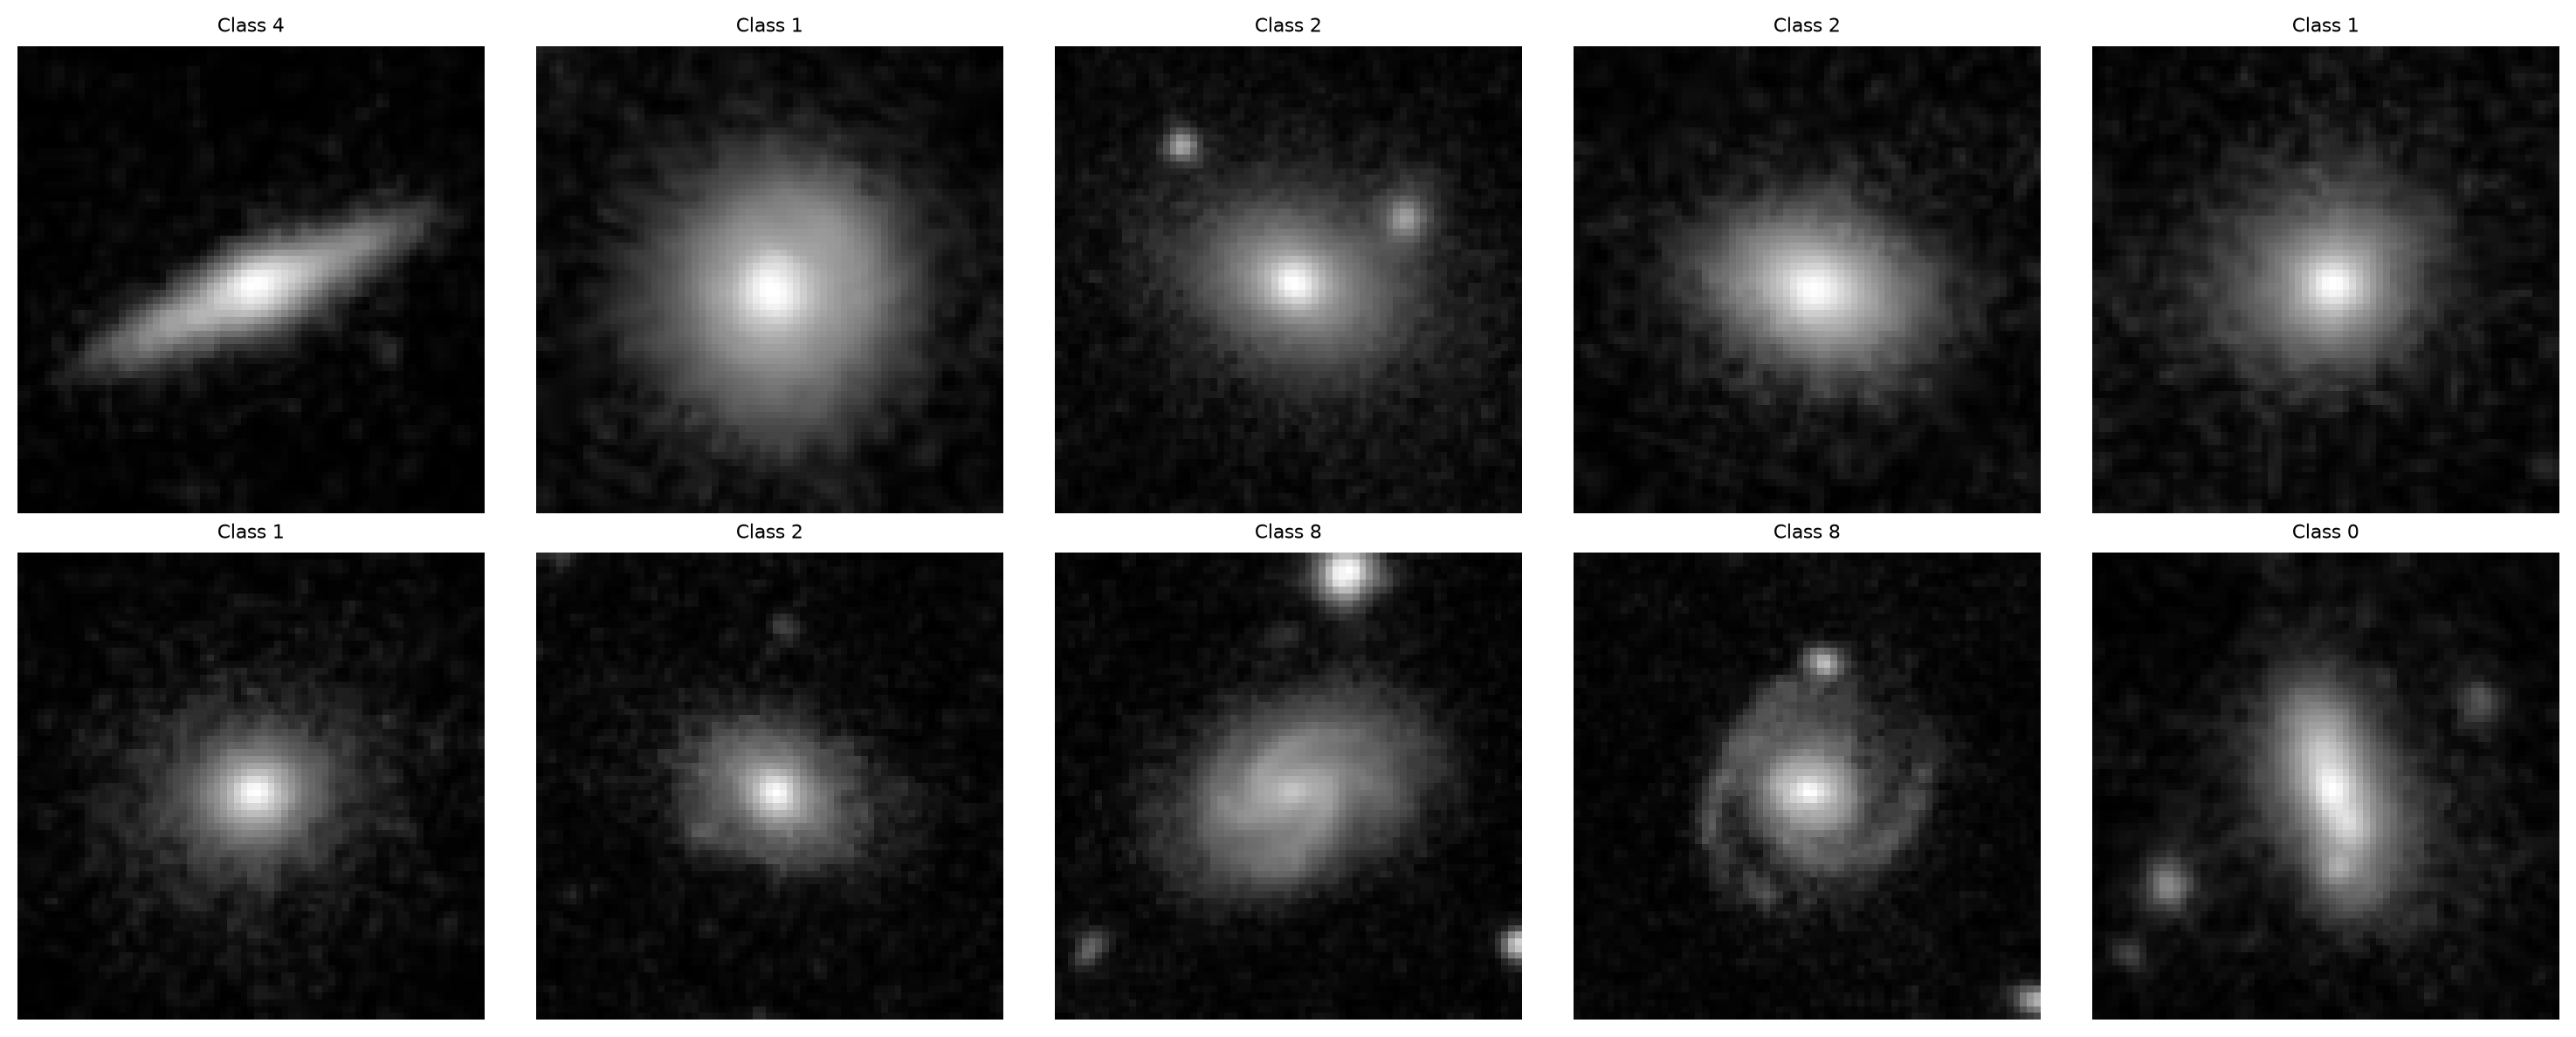

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, i in zip(axes.flat, idx):
    ax.imshow(X_train_gray[i], cmap="gray")
    ax.set_title(f"Class {np.argmax(y_train[i])}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Data Cleaning

1. normalization (min-max)
2. normalization using percentiles
3. gaussian / bilateral filter
4. histogram equalization

In [10]:
# Min-max normalization (per-image)

X_min = X_train_gray.min(axis=(1,2), keepdims=True)  
X_max = X_train_gray.max(axis=(1,2), keepdims=True)
X_norm = (X_train_gray - X_min) / (X_max - X_min + 1e-8)  

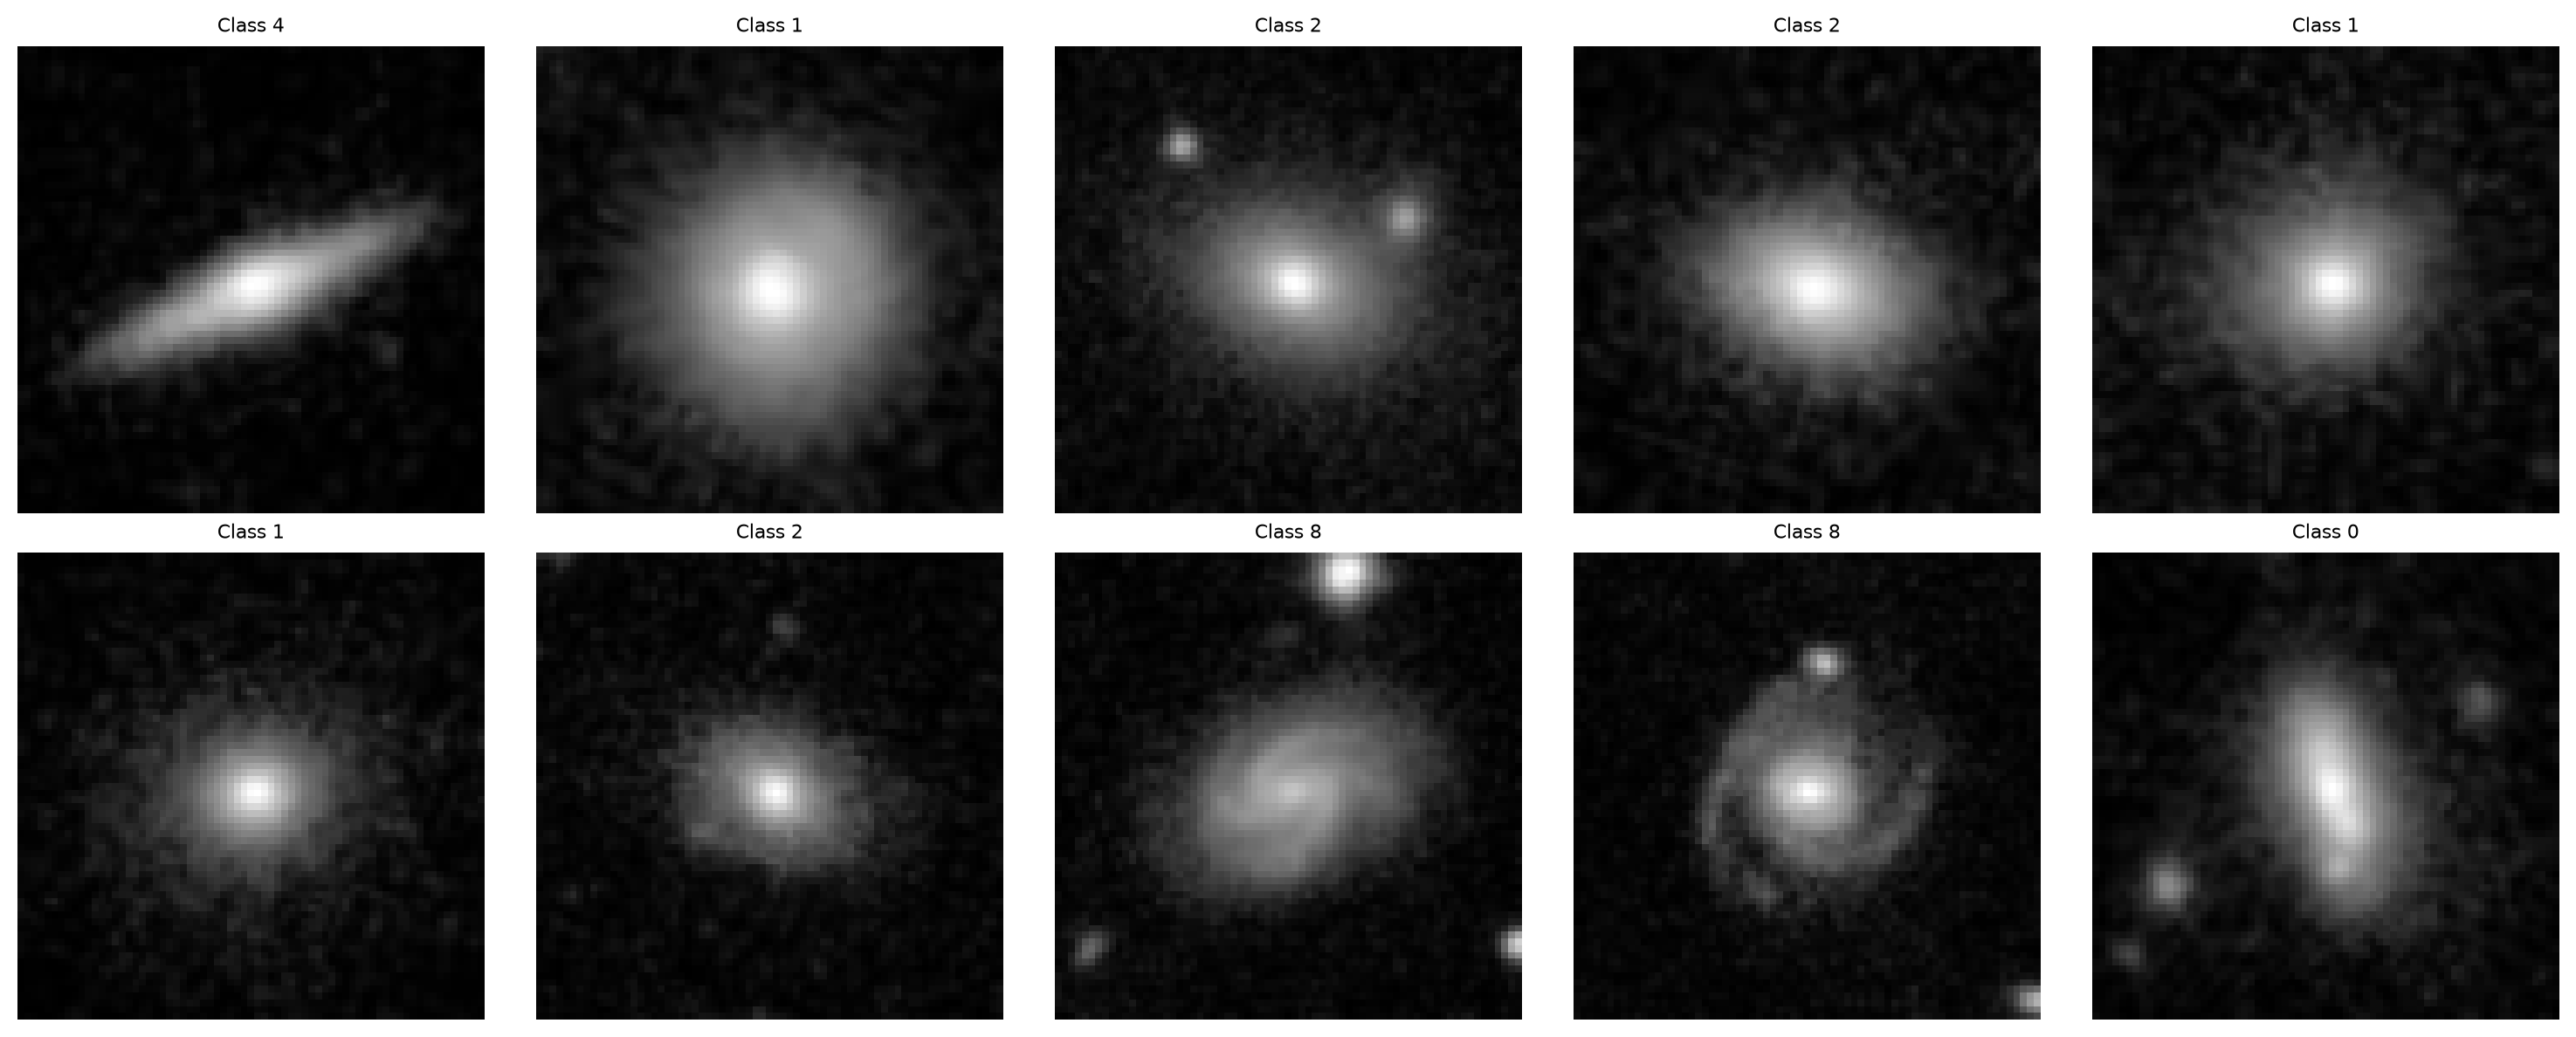

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, i in zip(axes.flat, idx):
    ax.imshow(X_norm[i], cmap="gray")
    ax.set_title(f"Class {np.argmax(y_train[i])}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
# plt.savefig("plots/gray.png")
plt.show()

In [12]:
X_norm.shape

(19606, 69, 69)

In [13]:
# gaussian filter on images

from scipy.ndimage import gaussian_filter

X_gauss = gaussian_filter(X_norm, sigma=1, axes=[1,2])

In [14]:
X_gauss.min(), X_gauss.max()

(0.0, 0.9974658839905133)

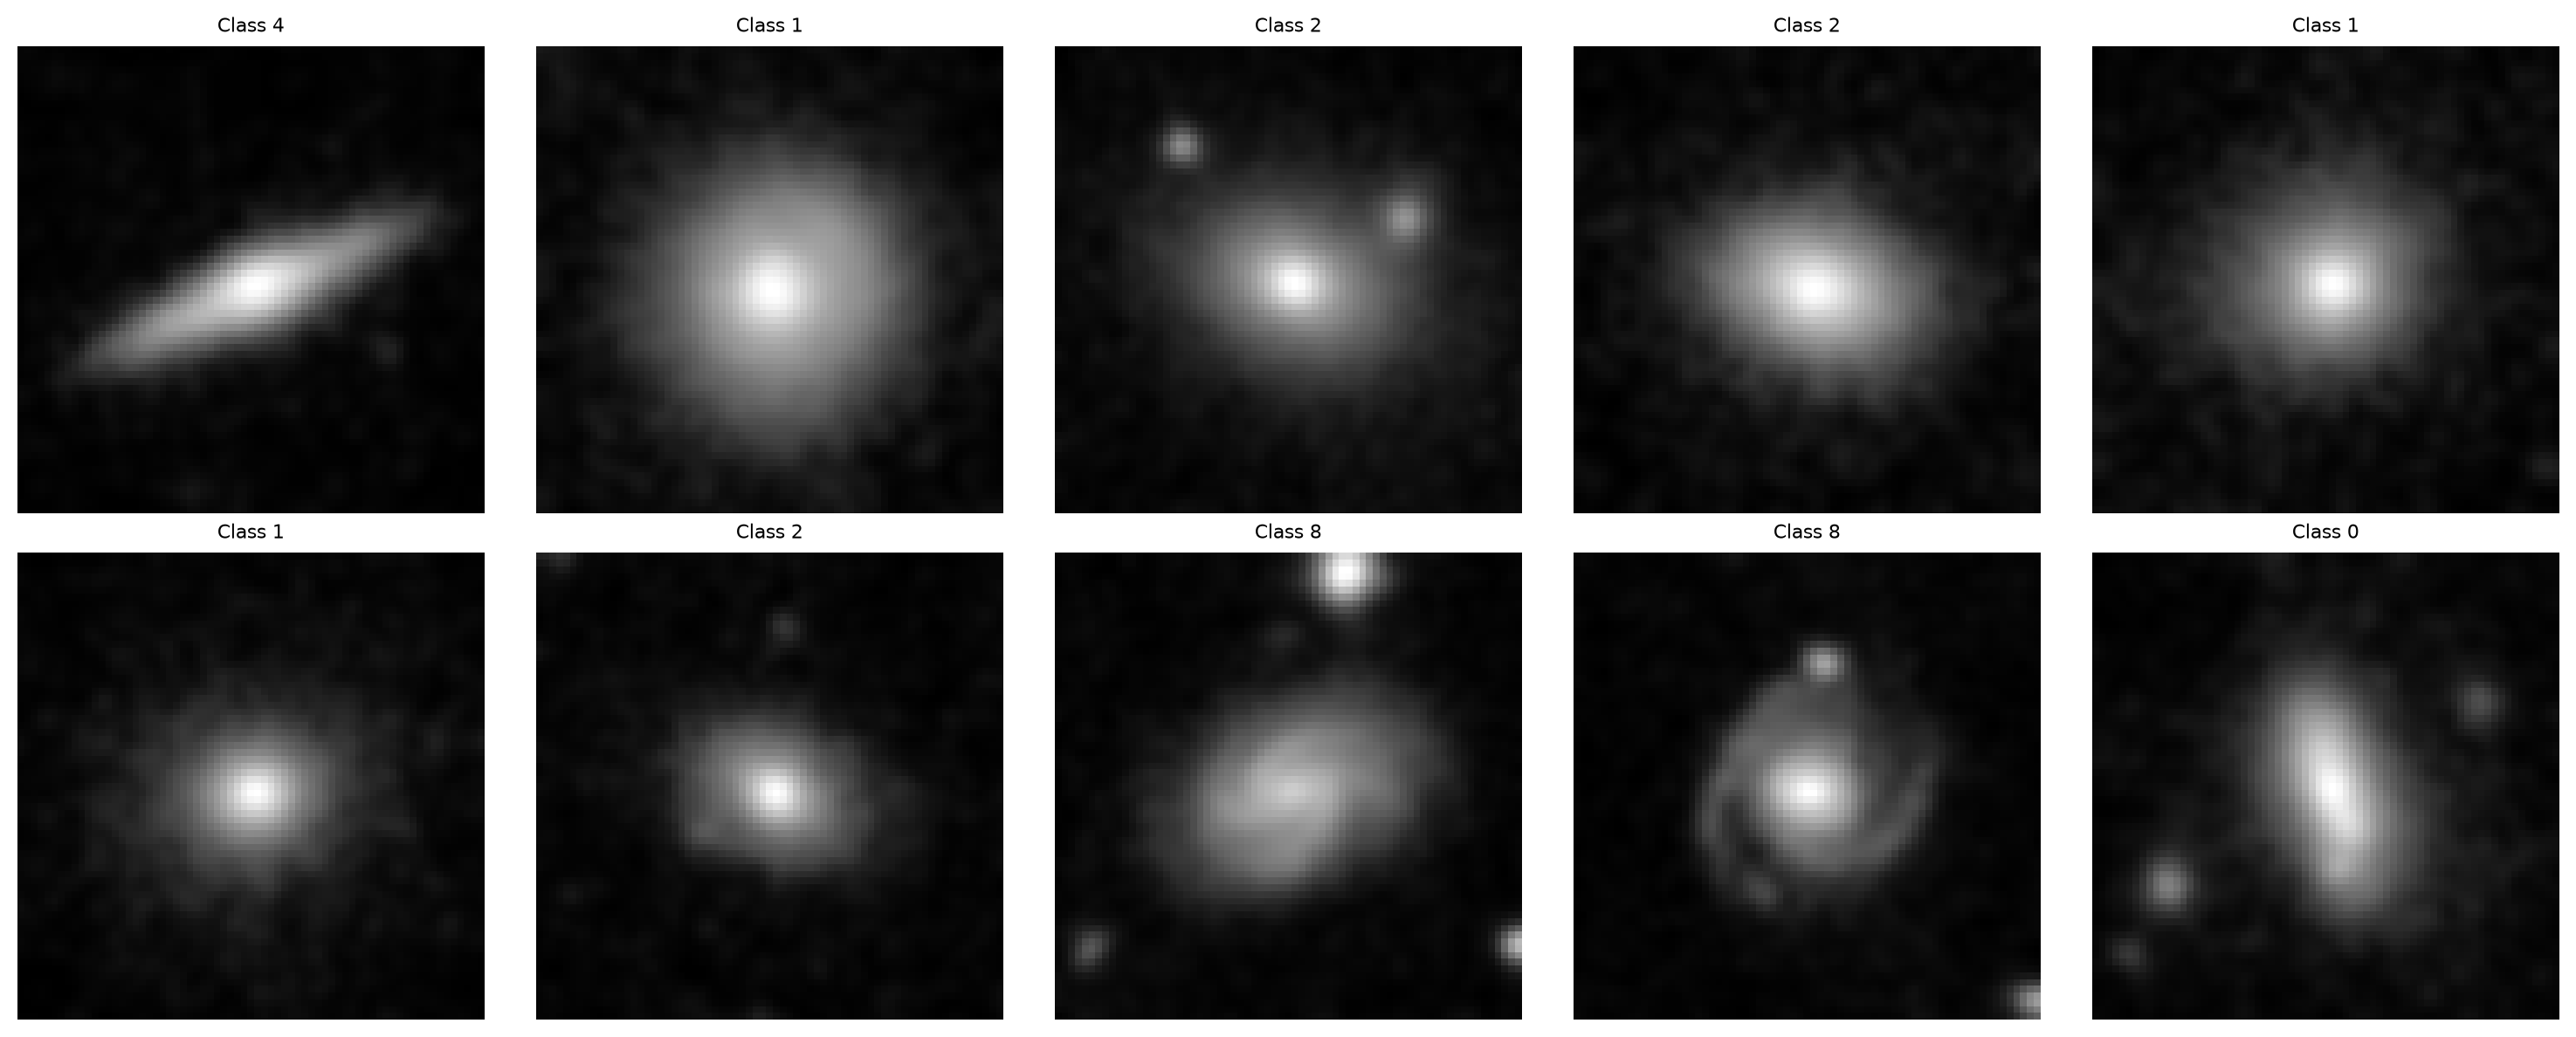

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, i in zip(axes.flat, idx):
    ax.imshow(X_gauss[i], cmap="gray")
    ax.set_title(f"Class {np.argmax(y_train[i])}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
# plt.savefig("plots/gaussian_smooth.png")
plt.show()

In [16]:
# train a model on X_norm (without filters) and X_gauss

X_norm.shape, y_train.shape

((19606, 69, 69), (19606, 10))

### Training

#### without filter

In [17]:
# train a CNN model

import tensorflow as tf
from keras import layers, models

In [18]:

input_shape = (X_norm.shape[1], X_norm.shape[1], 1)
model = models.Sequential()

# augmentation (only active during training)
model.add(layers.RandomFlip("horizontal_and_vertical"))
model.add(layers.RandomRotation(factor=0.5, fill_mode="reflect"))

model.add(layers.Input(shape=(69, 69, 1)))

# block 1
model.add(layers.Conv2D(8, (3, 3), activation="relu", padding="same"))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))

# block 2
model.add(layers.Conv2D(32, (5, 5), activation="relu", padding="same"))
model.add(layers.MaxPooling2D((2, 2)))

# block 3
model.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))

# converts feature maps → single vector per feature map
model.add(layers.GlobalAveragePooling2D())

model.add(layers.Dense(32, activation='relu'))

# model.add(layers.Dropout(0.4))

model.add(layers.Dense(10, activation='softmax'))

2026-08-01 21:56:19.535759: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-08-01 21:56:19.580385: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-08-01 21:56:19.580610: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [19]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["categorical_accuracy"]
)

In [20]:
X_norm.shape

(19606, 69, 69)

In [21]:
X_flat = X_norm[..., np.newaxis]
y_labels = np.argmax(y_train, axis=1)


In [22]:
X_flat.shape

(19606, 69, 69, 1)

In [23]:
y_train.shape

(19606, 10)

In [24]:
history = model.fit(
    X_flat, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    shuffle=True
)

2026-08-01 21:56:20.403332: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 298686096 exceeds 10% of free system memory.
2026-08-01 21:56:20.705778: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 298686096 exceeds 10% of free system memory.


Epoch 1/20


2026-08-01 21:56:22.675090: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-08-01 21:56:22.827809: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-08-01 21:56:22.917058: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-08-01 21:56:23.422725: I external/local_xla/xla/service/service.cc:168] XLA service 0x75ff91a72f50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-08-01 21:56:23.422747: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce GTX 1050, Compute Capability 6.1
2026-08-01 21:56:23.428906: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785614183.527696   16526 device_compiler.

491/491 [==============================] - 10s 13ms/step - loss: 1.2934 - categorical_accuracy: 0.4986 - val_loss: 1.6640 - val_categorical_accuracy: 0.4686
Epoch 2/20
491/491 [==============================] - 5s 10ms/step - loss: 0.8904 - categorical_accuracy: 0.6658 - val_loss: 1.0046 - val_categorical_accuracy: 0.6224
Epoch 3/20
491/491 [==============================] - 5s 10ms/step - loss: 0.7734 - categorical_accuracy: 0.7164 - val_loss: 0.8879 - val_categorical_accuracy: 0.6512
Epoch 4/20
491/491 [==============================] - 5s 11ms/step - loss: 0.7067 - categorical_accuracy: 0.7357 - val_loss: 1.0842 - val_categorical_accuracy: 0.6497
Epoch 5/20
491/491 [==============================] - 7s 15ms/step - loss: 0.6867 - categorical_accuracy: 0.7453 - val_loss: 0.7303 - val_categorical_accuracy: 0.7264
Epoch 6/20
491/491 [==============================] - 7s 15ms/step - loss: 0.6623 - categorical_accuracy: 0.7567 - val_loss: 0.6724 - val_categorical_accuracy: 0.7496
Epoch 7/

In [25]:
train_loss = history.history['loss']
train_acc = history.history['categorical_accuracy']
val_loss = history.history['val_loss']
val_acc = history.history['val_categorical_accuracy']

print(f'train loss: {train_loss}')
print(f'train acc: {train_acc}')
print(f'val loss: {val_loss}')
print(f'val acc: {val_acc}')

train loss: [1.2934068441390991, 0.8903979659080505, 0.773419976234436, 0.7067339420318604, 0.6867007613182068, 0.6622689962387085, 0.6449310779571533, 0.6347244381904602, 0.6120719909667969, 0.6007392406463623, 0.6016058325767517, 0.595880925655365, 0.5885619521141052, 0.580401599407196, 0.5770664215087891, 0.579072117805481, 0.5649911761283875, 0.5645452737808228, 0.5620161890983582, 0.5442723631858826]
train acc: [0.49859729409217834, 0.6657740473747253, 0.7163988947868347, 0.7357179522514343, 0.7453455924987793, 0.7566947340965271, 0.7570772767066956, 0.7635169625282288, 0.7733996510505676, 0.7779902815818787, 0.7800306081771851, 0.7788829207420349, 0.780795693397522, 0.787044107913971, 0.7865977883338928, 0.7865977883338928, 0.7922086119651794, 0.7895944714546204, 0.7911884784698486, 0.7994771599769592]
val loss: [1.6639890670776367, 1.0045803785324097, 0.8878813982009888, 1.0842061042785645, 0.7302982211112976, 0.6724189519882202, 0.7832685708999634, 0.8248935341835022, 0.6995294

In [26]:
y_pred = model.predict(X_flat)

2026-08-01 21:58:13.949871: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 373376664 exceeds 10% of free system memory.
2026-08-01 21:58:14.309503: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 373376664 exceeds 10% of free system memory.


613/613 [==============================] - 2s 3ms/step


In [27]:
y_pred = np.argmax(y_pred, axis=1)

In [28]:
y_true = np.argmax(y_train, axis=1)

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_pred, y_true)

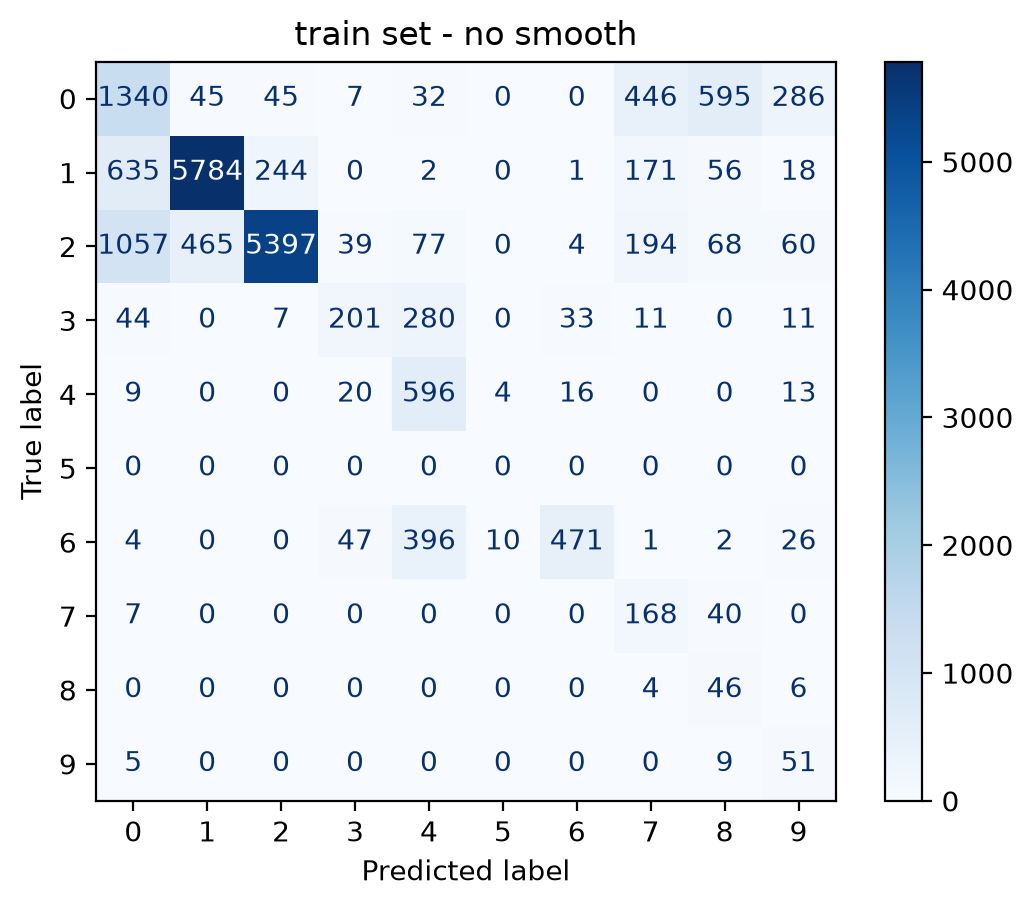

In [30]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("train set - no smooth")
# plt.savefig("plots/train_no_smooth.pdf")
plt.show()

#### with filter

In [31]:
X_flat_gauss = X_gauss[..., np.newaxis]

input_shape = (X_norm.shape[1], X_norm.shape[1], 1)
gauss_model = models.Sequential()

# augmentation (only active during training)
gauss_model.add(layers.RandomFlip("horizontal_and_vertical"))
gauss_model.add(layers.RandomRotation(factor=0.5, fill_mode="reflect"))

gauss_model.add(layers.Input(shape=(69, 69, 1)))

# block 1
gauss_model.add(layers.Conv2D(8, (3, 3), activation="relu", padding="same"))
gauss_model.add(layers.BatchNormalization())
gauss_model.add(layers.MaxPooling2D((2, 2)))

# block 2
gauss_model.add(layers.Conv2D(32, (5, 5), activation="relu", padding="same"))
gauss_model.add(layers.MaxPooling2D((2, 2)))

# block 3
gauss_model.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
gauss_model.add(layers.BatchNormalization())
gauss_model.add(layers.MaxPooling2D((2, 2)))

# converts feature maps → single vector per feature map
gauss_model.add(layers.GlobalAveragePooling2D())

gauss_model.add(layers.Dense(32, activation='relu'))

# model.add(layers.Dropout(0.4))

gauss_model.add(layers.Dense(10, activation='softmax'))

In [32]:
gauss_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["categorical_accuracy"]
)

In [33]:
history = gauss_model.fit(
    X_flat_gauss, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    shuffle=True
)

2026-08-01 21:58:17.809227: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 298686096 exceeds 10% of free system memory.


Epoch 1/20
491/491 [==============================] - 7s 11ms/step - loss: 1.2522 - categorical_accuracy: 0.5303 - val_loss: 1.6184 - val_categorical_accuracy: 0.4294
Epoch 2/20
491/491 [==============================] - 5s 10ms/step - loss: 0.8443 - categorical_accuracy: 0.6890 - val_loss: 0.9821 - val_categorical_accuracy: 0.6387
Epoch 3/20
491/491 [==============================] - 5s 10ms/step - loss: 0.7411 - categorical_accuracy: 0.7273 - val_loss: 0.8878 - val_categorical_accuracy: 0.6632
Epoch 4/20
491/491 [==============================] - 5s 10ms/step - loss: 0.6927 - categorical_accuracy: 0.7454 - val_loss: 0.8209 - val_categorical_accuracy: 0.6820
Epoch 5/20
491/491 [==============================] - 5s 10ms/step - loss: 0.6769 - categorical_accuracy: 0.7472 - val_loss: 0.7506 - val_categorical_accuracy: 0.7264
Epoch 6/20
491/491 [==============================] - 5s 10ms/step - loss: 0.6467 - categorical_accuracy: 0.7614 - val_loss: 0.6971 - val_categorical_accuracy: 0.734

In [34]:
train_loss = history.history['loss']
train_acc = history.history['categorical_accuracy']
val_loss = history.history['val_loss']
val_acc = history.history['val_categorical_accuracy']

print(f'train loss: {train_loss}')
print(f'train acc: {train_acc}')
print(f'val loss: {val_loss}')
print(f'val acc: {val_acc}')

train loss: [1.2522019147872925, 0.8442625403404236, 0.7411236763000488, 0.6927047967910767, 0.6768683195114136, 0.6467489004135132, 0.6339564323425293, 0.6192782521247864, 0.60930997133255, 0.6030876040458679, 0.5912905335426331, 0.582405149936676, 0.5799487233161926, 0.5690973401069641, 0.5664665699005127, 0.5603009462356567, 0.5558974742889404, 0.5483840703964233, 0.548839807510376, 0.5418325662612915]
train acc: [0.5303493738174438, 0.6889824271202087, 0.7273017168045044, 0.7454093098640442, 0.7471945881843567, 0.7614129185676575, 0.7685539126396179, 0.7716143727302551, 0.7733996510505676, 0.7742922902107239, 0.7811145186424255, 0.7869166135787964, 0.7858327031135559, 0.7878729701042175, 0.7883830666542053, 0.7941851615905762, 0.7960979342460632, 0.7941213846206665, 0.7988395690917969, 0.8036853075027466]
val loss: [1.6184355020523071, 0.9821145534515381, 0.8878360986709595, 0.8208656311035156, 0.75062495470047, 0.6971203684806824, 0.909845769405365, 0.9895896911621094, 0.710247933

In [35]:
y_gauss = gauss_model.predict(X_flat_gauss)
y_pred = np.argmax(y_gauss, axis=1)

613/613 [==============================] - 2s 3ms/step


In [36]:
y_true = np.argmax(y_train, axis=1)

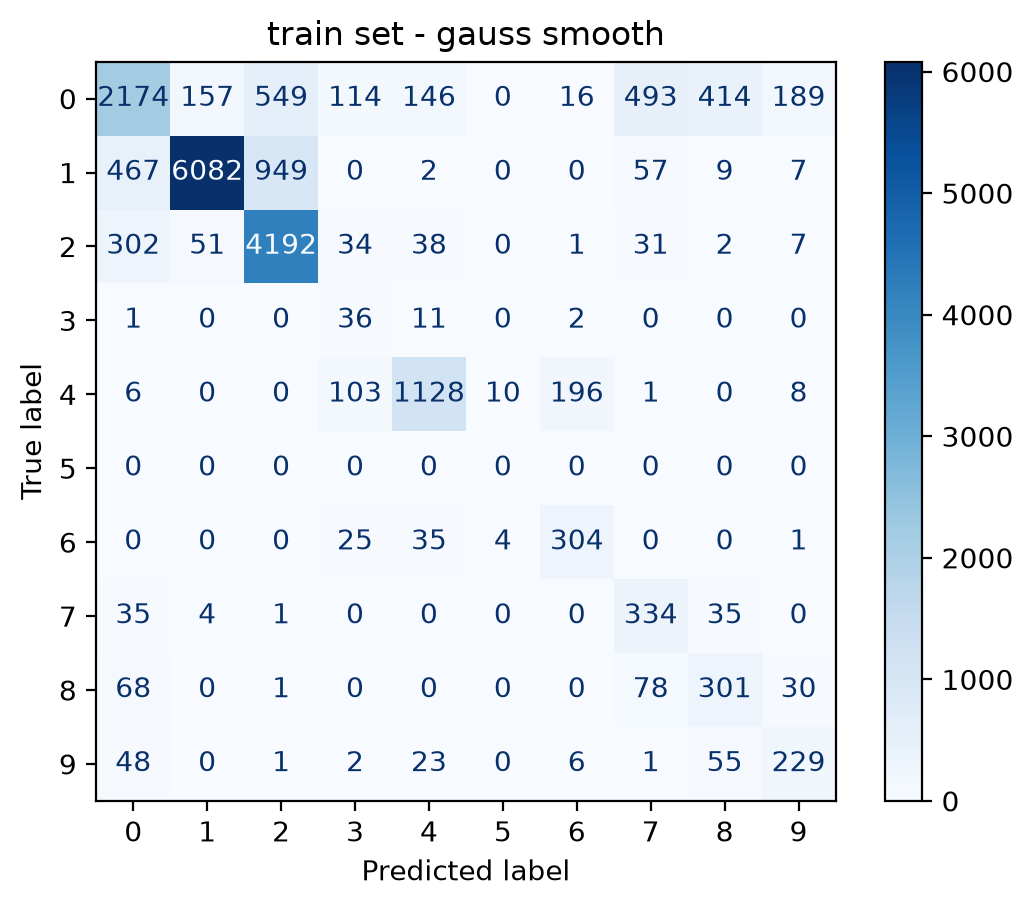

In [37]:
cm = confusion_matrix(y_pred, y_true)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("train set - gauss smooth")
# plt.savefig("plots/train_gauss_smooth.pdf")
plt.show()

### Testing

#### without filter

In [38]:
X_test_gray.shape

(2179, 69, 69)

In [39]:
# Min-max normalization (per-image)

X_min = X_test_gray.min(axis=(1,2), keepdims=True)  
X_max = X_test_gray.max(axis=(1,2), keepdims=True)
X_norm = (X_test_gray - X_min) / (X_max - X_min + 1e-8)  

In [40]:
X_flat = X_norm[..., np.newaxis]
y_labels = np.argmax(y_test, axis=1)

In [41]:
y_pred = model.predict(X_flat)
y_pred = np.argmax(y_pred, axis=1)

69/69 [==============================] - 0s 6ms/step


In [42]:
y_true = np.argmax(y_test, axis=1)

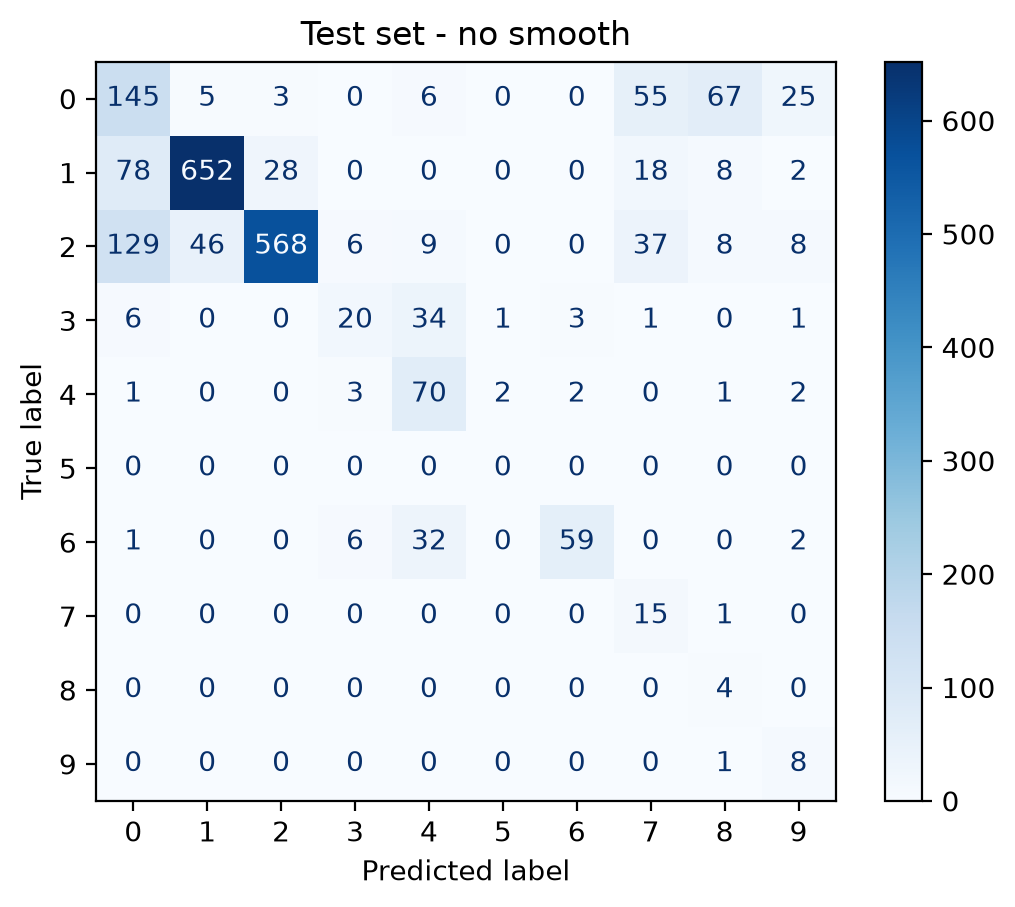

In [43]:
cm = confusion_matrix(y_pred, y_true)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Test set - no smooth")
# plt.savefig("plots/test_no_smooth.pdf")
plt.show()

In [44]:
# accuracy

acc = np.mean(y_true == y_pred)
print(f"Test set accuracy (without smooth) : {acc:.4f}")

Test set accuracy (without smooth) : 0.7072


In [45]:
# precision: TP / (TP + FP)
# recall:    TP / (TP + FN)

tps = np.diagonal(cm)
fps_matrix = cm.copy()
np.fill_diagonal(fps_matrix, 0)
fps = np.sum(fps_matrix, axis=0)
fns = np.sum(fps_matrix, axis=1)

In [46]:
import numpy as np

precisions = np.divide(tps, tps + fps, out=np.zeros_like(tps, dtype=float), where=(tps + fps) != 0)
recalls = np.divide(tps, tps + fns, out=np.zeros_like(tps, dtype=float), where=(tps + fns) != 0)
# f1s = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(precision), where=(precision + recall) != 0)

In [47]:
print("Test set performance (no smooth)")
print(f"precision: {np.mean(precisions)}")
print(f"recall: {np.mean(recalls)}")

Test set performance (no smooth)
precision: 0.4565517086328616
recall: 0.6587359385060726


In [48]:
X_min = X_test_gray.min(axis=(1,2), keepdims=True)  
X_max = X_test_gray.max(axis=(1,2), keepdims=True)
X_norm = (X_test_gray - X_min) / (X_max - X_min + 1e-8)  

X_gauss = gaussian_filter(X_norm, sigma=1, axes=[1,2])
X_flat = X_gauss[..., np.newaxis]

In [49]:
y_pred = gauss_model.predict(X_flat)
y_pred = np.argmax(y_pred, axis=1)

69/69 [==============================] - 0s 3ms/step


#### with filter

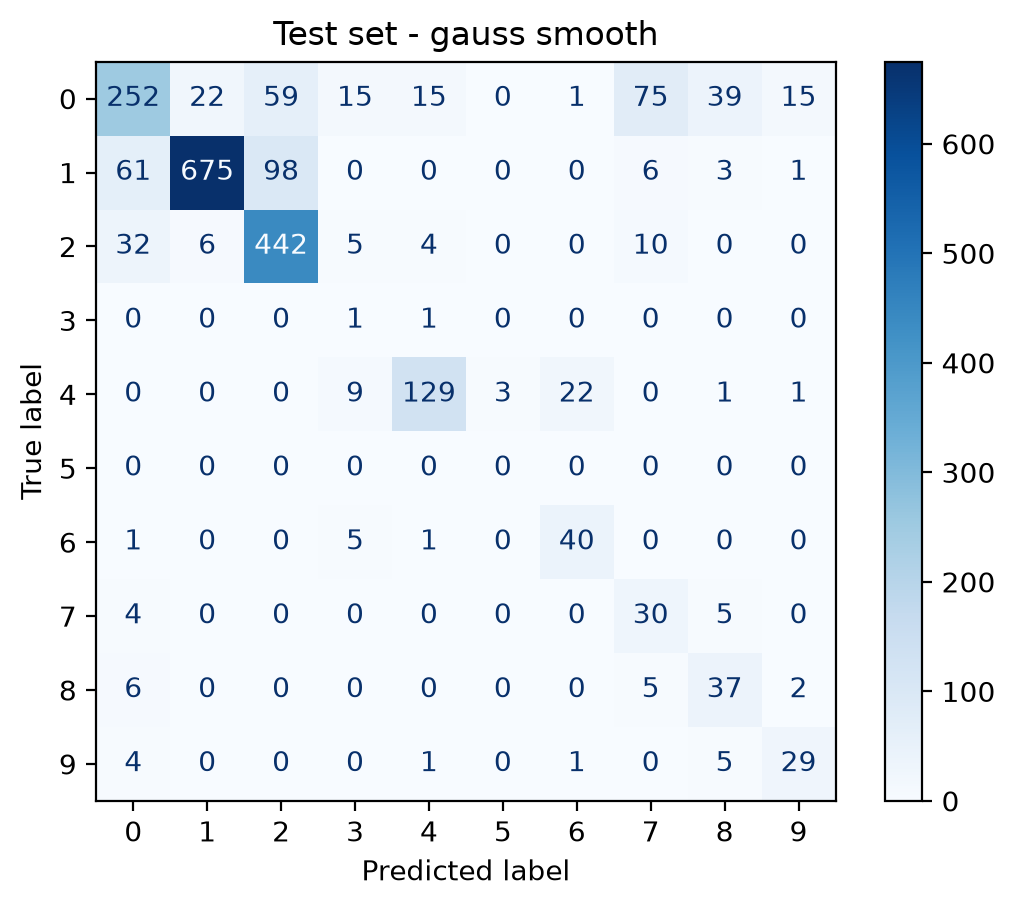

In [50]:
cm = confusion_matrix(y_pred, y_true)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Test set - gauss smooth")
# plt.savefig("plots/test_gauss_smooth.pdf")
plt.show()

In [51]:
# accuracy

acc = np.mean(y_true == y_pred)
print(f"Test set accuracy (smooth) : {acc:.4f}")

Test set accuracy (smooth) : 0.7503


In [52]:
# precision: TP / (TP + FP)
# recall:    TP / (TP + FN)

tps = np.diagonal(cm)
fps_matrix = cm.copy()
np.fill_diagonal(fps_matrix, 0)
fps = np.sum(fps_matrix, axis=0)
fns = np.sum(fps_matrix, axis=1)

In [53]:
import numpy as np

precisions = np.divide(tps, tps + fps, out=np.zeros_like(tps, dtype=float), where=(tps + fps) != 0)
recalls = np.divide(tps, tps + fns, out=np.zeros_like(tps, dtype=float), where=(tps + fns) != 0)
# f1s = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(precision), where=(precision + recall) != 0)

In [54]:
print("Test set performance (smooth)")
print(f"precision: {np.mean(precisions)}")
print(f"recall: {np.mean(recalls)}")

Test set performance (smooth)
precision: 0.5159316271375765
recall: 0.6563803543710289


### Network inspect

1/1 [==============================] - 0s 247ms/step


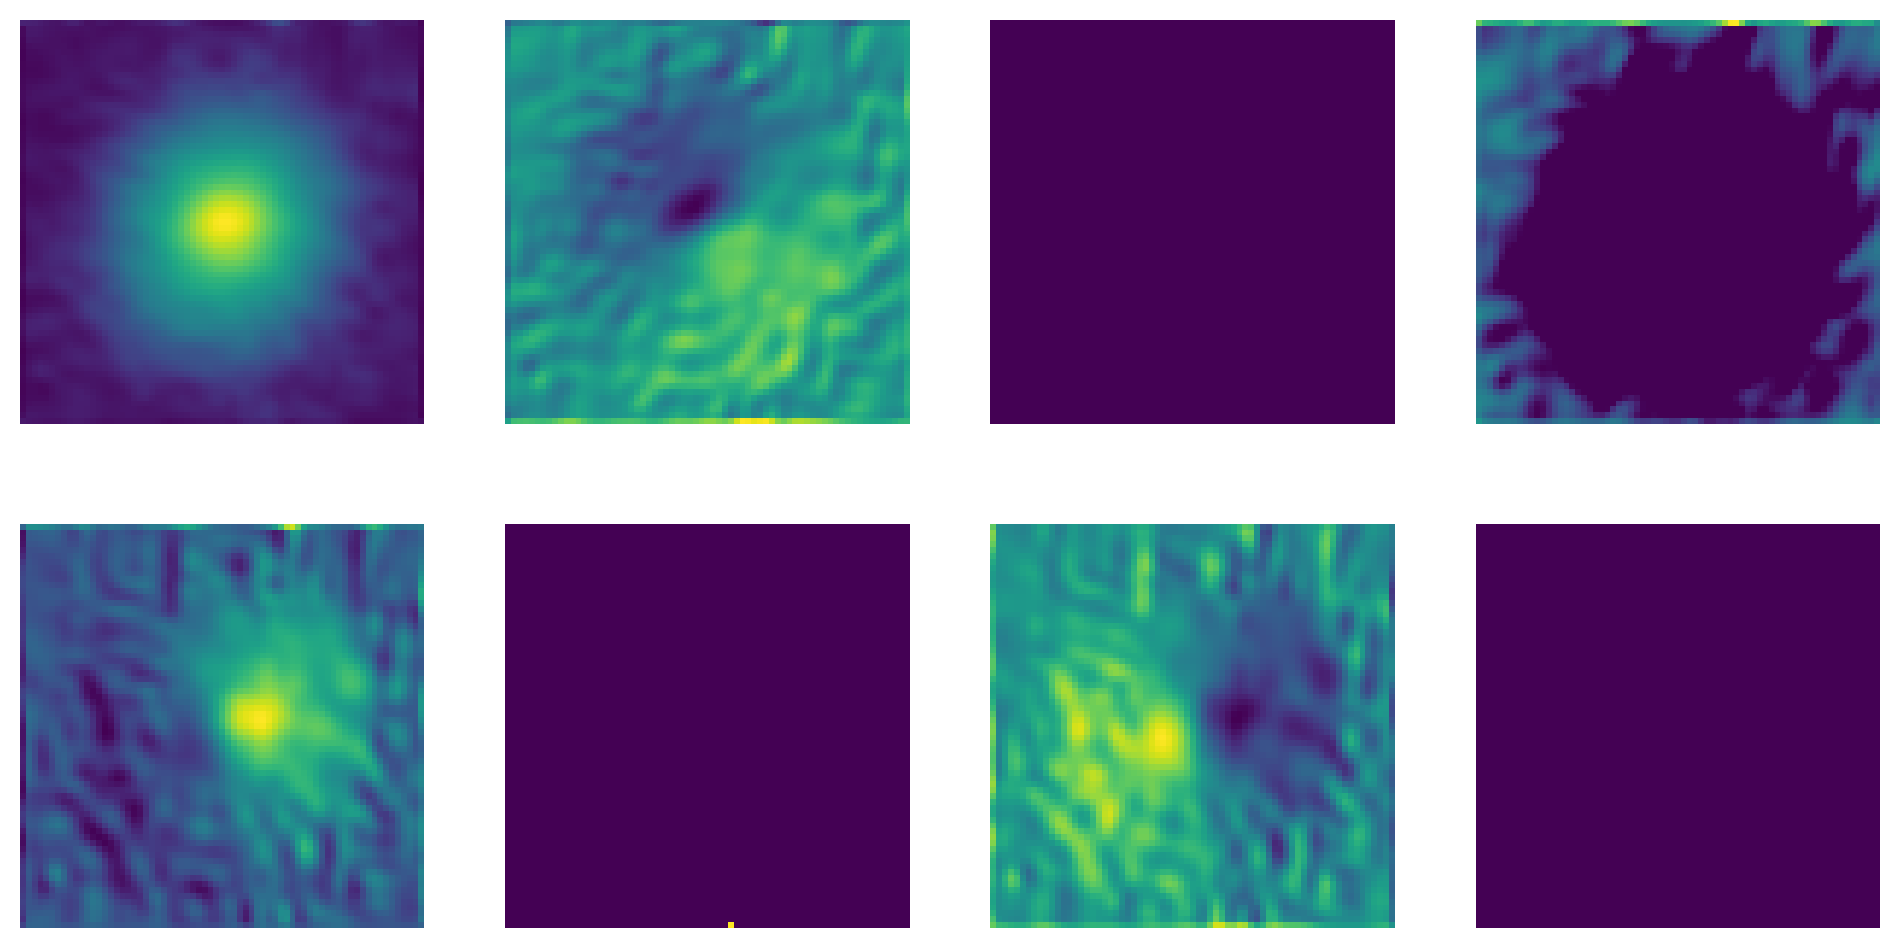

In [55]:
from tensorflow.keras.models import Model

layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name]
activation_model = Model(inputs=model.input, outputs=layer_outputs)

img = X_flat_gauss[0:1]  # one sample, shape (1, 69, 69, 1)
activations = activation_model.predict(img)

first_layer_activation = activations[0]  # (1, 69, 69, 8)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(first_layer_activation[0, :, :, i], cmap='viridis')
    ax.axis('off')
# plt.title("1st layer feature map - no smooth")
# plt.savefig("plots/1LayerFM_no_smooth.png")
plt.show()

1/1 [==============================] - 0s 59ms/step


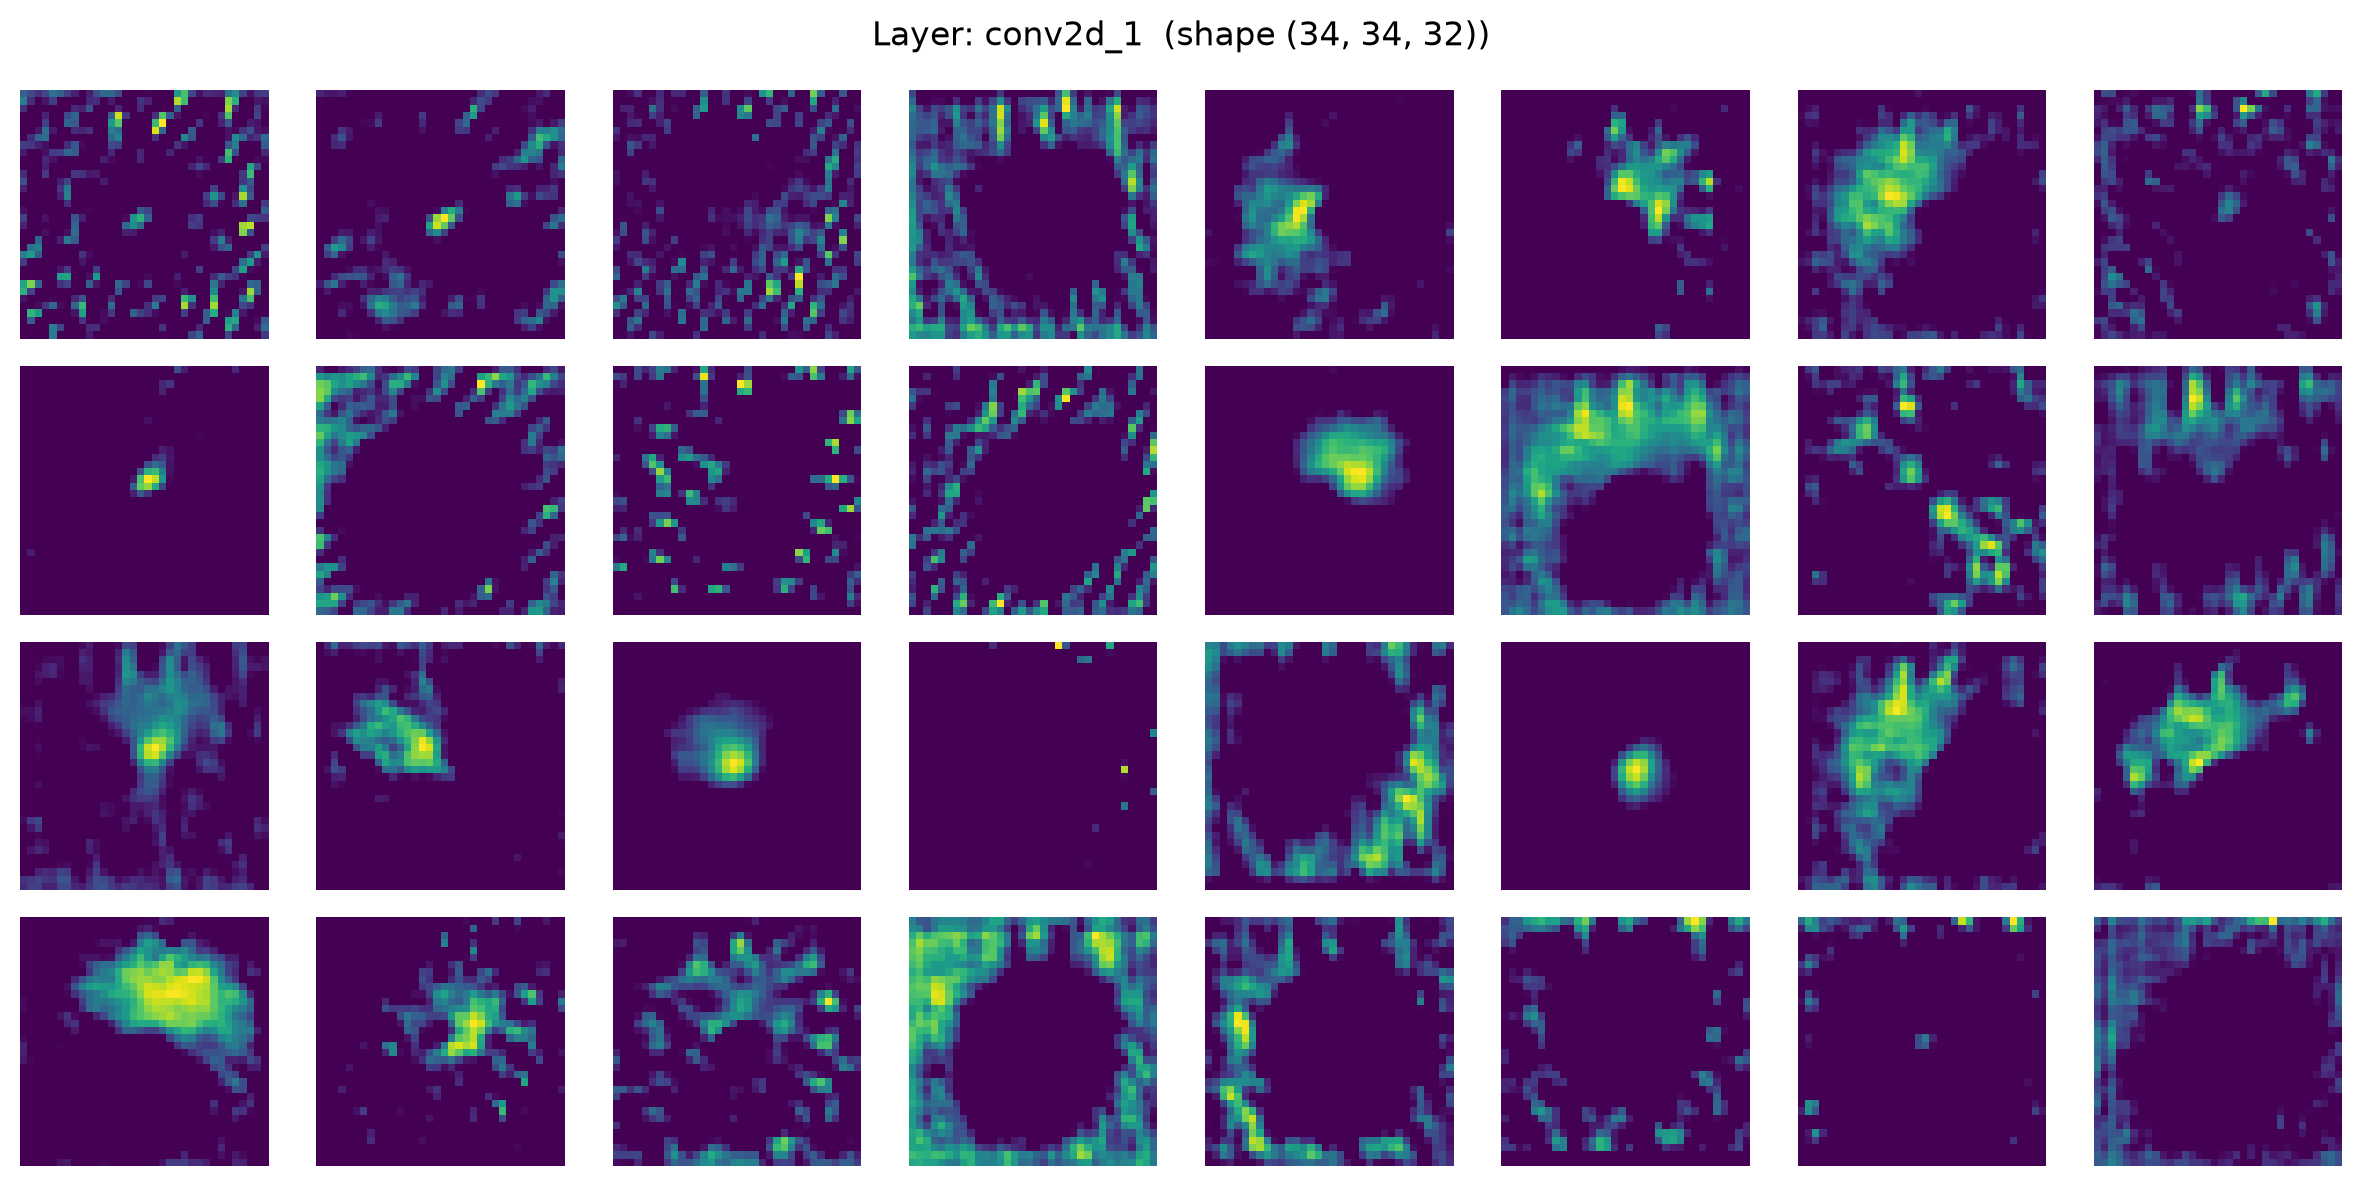

In [56]:
# 2. Grab every conv layer's output
conv_layers = [layer for layer in model.layers if 'conv' in layer.name]
layer_outputs = [layer.output for layer in conv_layers]
layer_names = [layer.name for layer in conv_layers]

activation_model = Model(inputs=model.input, outputs=layer_outputs)
activations = activation_model.predict(img)

# 3. Plot ONLY the second conv layer (index 1)
layer_name = layer_names[1]
activation = activations[1]

n_channels = activation.shape[-1]
n_cols = 8
n_rows = int(np.ceil(n_channels / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.5, n_rows * 1.5))
fig.suptitle(f"Layer: {layer_name}  (shape {activation.shape[1:]})", fontsize=12)

for i, ax in enumerate(axes.flat):
    if i < n_channels:
        ax.imshow(activation[0, :, :, i], cmap='viridis')
    ax.axis('off')

plt.tight_layout()
# plt.title("2nd layer feature map - no smooth")
# plt.savefig("plots/2LayerFM_no_smooth.pdf")
plt.show()

1/1 [==============================] - 0s 62ms/step


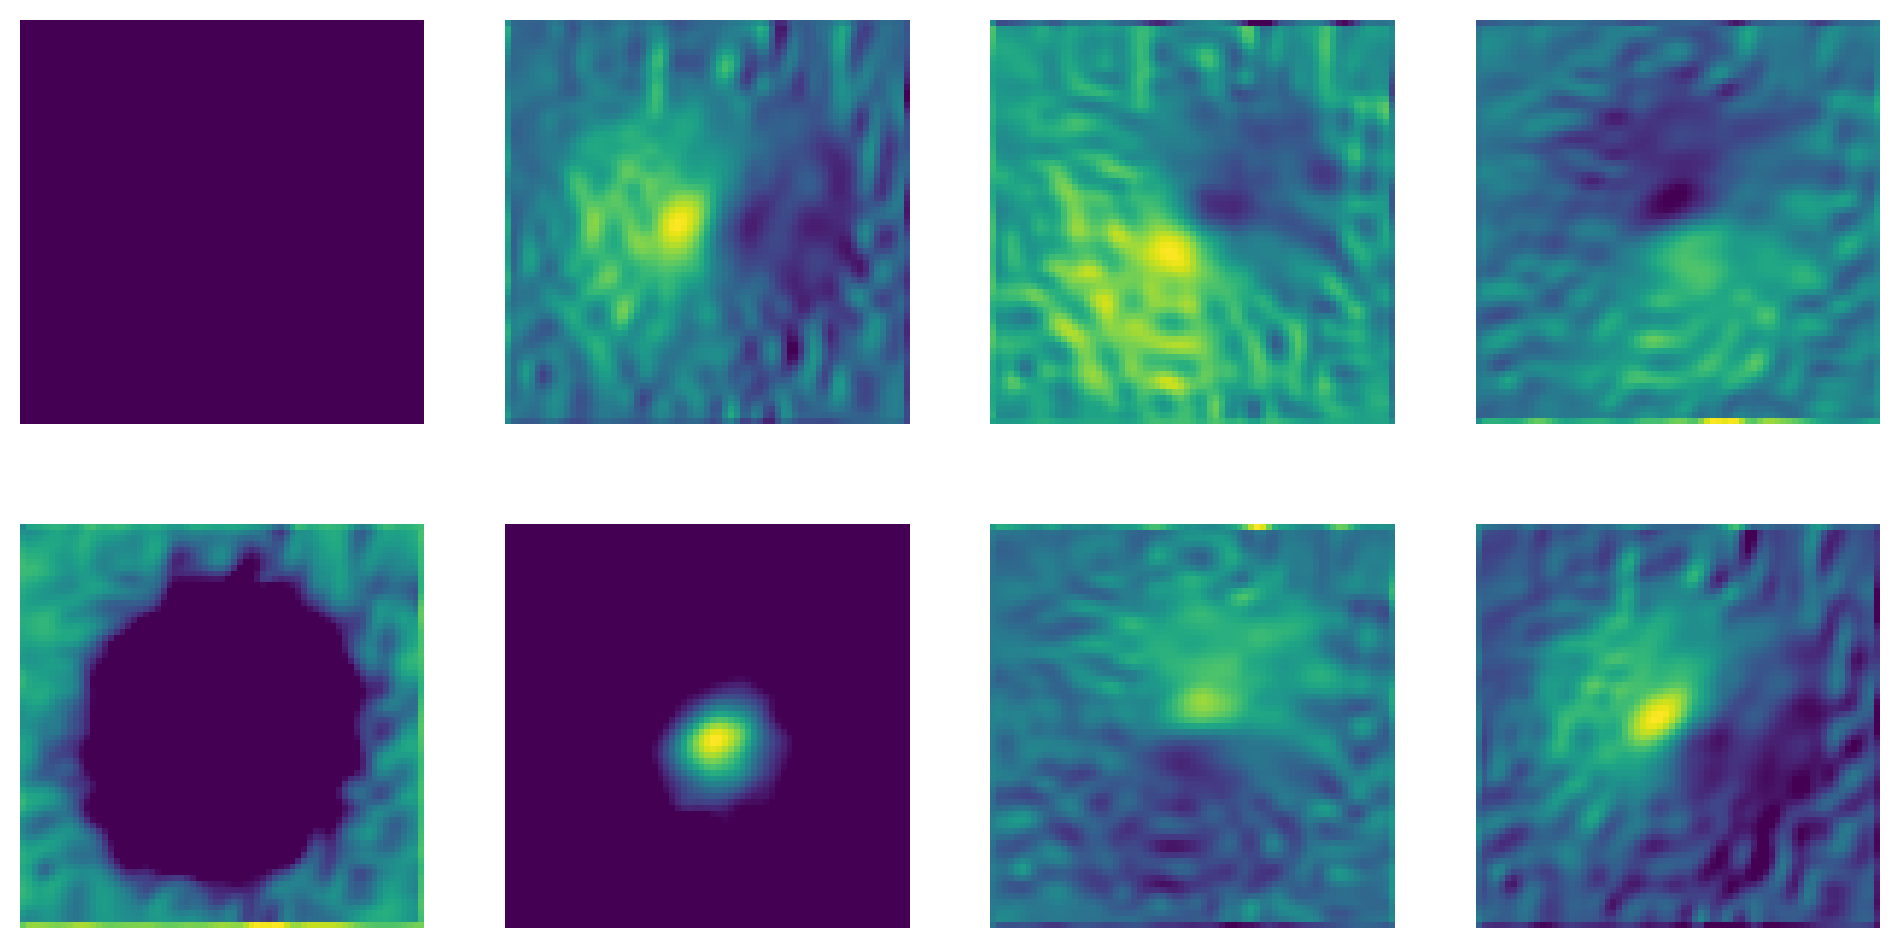

In [57]:
layer_outputs = [layer.output for layer in gauss_model.layers if 'conv' in layer.name]
activation_model = Model(inputs=gauss_model.input, outputs=layer_outputs)

img = X_flat_gauss[0:1]  # one sample, shape (1, 69, 69, 1)
activations = activation_model.predict(img)

first_layer_activation = activations[0]  # (1, 69, 69, 8)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(first_layer_activation[0, :, :, i], cmap='viridis')
    ax.axis('off')
# plt.title("1st layer feature map - gauss smooth")
# plt.savefig("plots/1LayerFM_gauss_smooth.png")
plt.show()

1/1 [==============================] - 0s 60ms/step


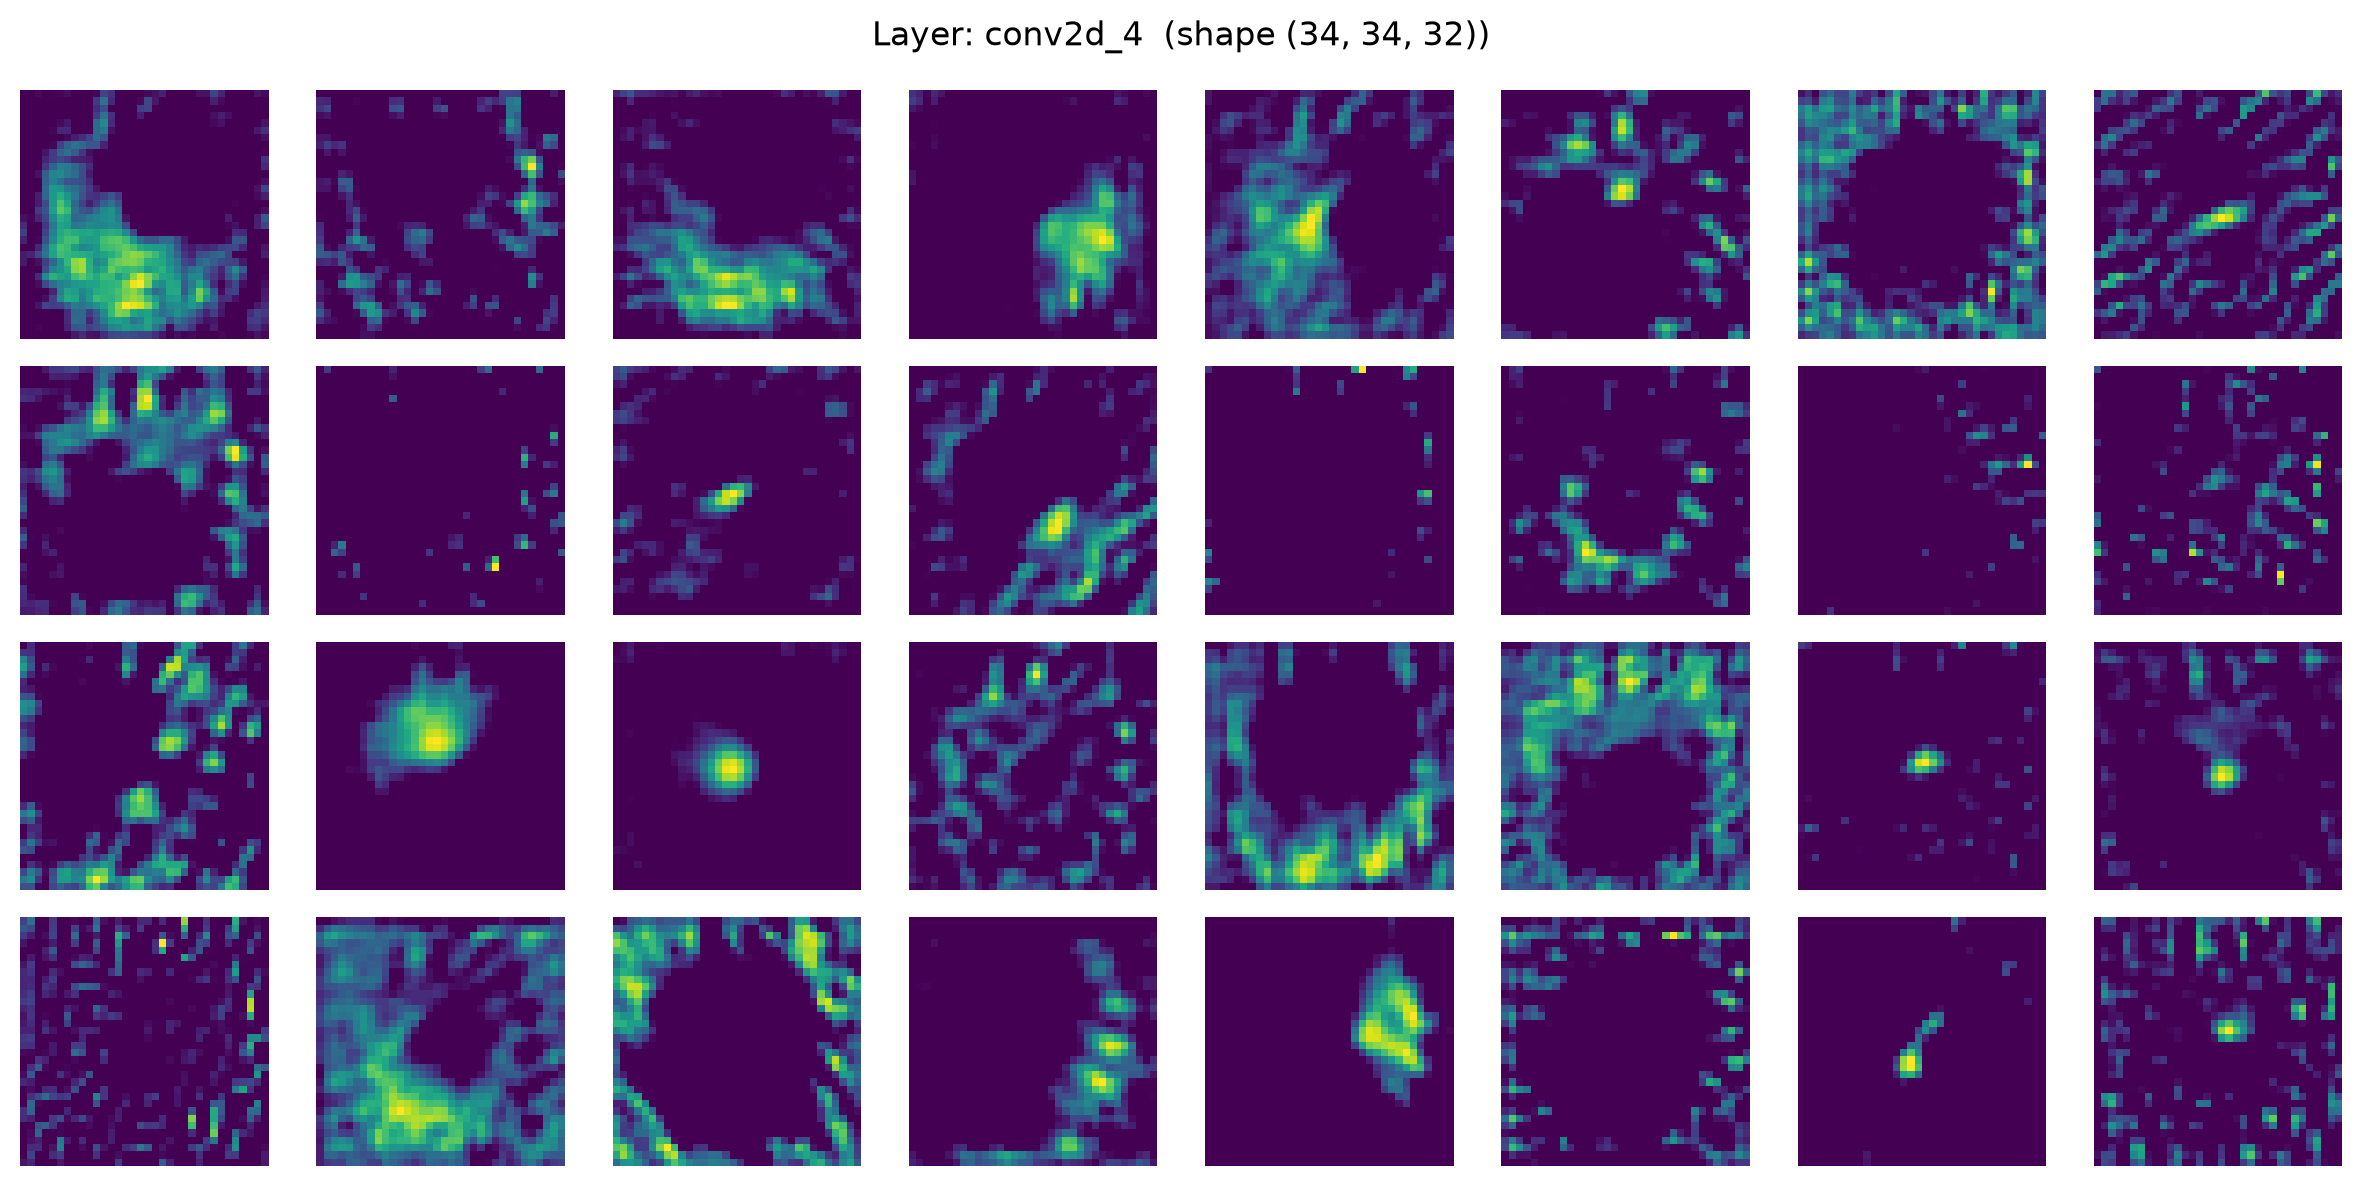

In [58]:
# 2. Grab every conv layer's output
conv_layers = [layer for layer in gauss_model.layers if 'conv' in layer.name]
layer_outputs = [layer.output for layer in conv_layers]
layer_names = [layer.name for layer in conv_layers]

activation_model = Model(inputs=gauss_model.input, outputs=layer_outputs)
activations = activation_model.predict(img)

# 3. Plot ONLY the second conv layer (index 1)
layer_name = layer_names[1]
activation = activations[1]

n_channels = activation.shape[-1]
n_cols = 8
n_rows = int(np.ceil(n_channels / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.5, n_rows * 1.5))
fig.suptitle(f"Layer: {layer_name}  (shape {activation.shape[1:]})", fontsize=12)

for i, ax in enumerate(axes.flat):
    if i < n_channels:
        ax.imshow(activation[0, :, :, i], cmap='viridis')
    ax.axis('off')

plt.tight_layout()
# plt.title("2nd layer feature map - gauss smooth")
# plt.savefig("plots/2LayerFM_gauss_smooth.pdf")
plt.show()